# Thai Sign Language — Data Preprocessing Pipeline

> Converts raw `.mp4` sign language videos into normalized, augmented keypoint arrays  
> ready for deep learning training.

**Pipeline overview:**
```
video.mp4
  └─ MediaPipe Holistic  →  raw keypoints (n_frames, D)
       └─ compute_features  →  (n_frames, D*2+2)
            └─ normalize_sequence  →  (60, D*2+2)
                 └─ augment_sequence  →  80 × (60, D*2+2) .npy files
                      └─ build_dataset  →  X_train / X_val arrays
```

| Cell | Purpose |
|------|---------|
| 1 | Imports & config |
| 2 | Load metadata & build class index |
| 3 | `extract_keypoints()` — MediaPipe holistic |
| 4 | `compute_features()` — velocity + hand stats |
| 5 | `normalize_sequence()` — resample + z-score |
| 6 | `augment_sequence()` — 17→80 variants |
| 7 | Run full pipeline on all train videos |
| 8 | Build and save `X_train / X_val` arrays |
| 9 | Sanity-check visualization |

---
## Cell 1 — Imports & Configuration

In [2]:
import json
import os
import random
import warnings
from pathlib import Path
from collections import defaultdict

import cv2
import mediapipe as mp
import numpy as np

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

# ── Configuration ─────────────────────────────────────────────────────────────
CONFIG = {
    'DATA_DIR'      : '../demo_data',
    'OUTPUT_DIR'    : '../demo_data/processed',
    'TARGET_FRAMES' : 60,
    'EXTRACT_FACE'  : False,
    'EXTRACT_POSE'  : True,
    'EXTRACT_HANDS' : True,
    # Val and test are saved WITHOUT augmentation (1 sample per source video).
    # Training uses 30 online augments per source video via tf.data.
}

DATA_DIR      = Path(CONFIG['DATA_DIR'])
OUTPUT_DIR    = Path(CONFIG['OUTPUT_DIR'])
TARGET_FRAMES = CONFIG['TARGET_FRAMES']
EXTRACT_FACE  = CONFIG['EXTRACT_FACE']
EXTRACT_POSE  = CONFIG['EXTRACT_POSE']
EXTRACT_HANDS = CONFIG['EXTRACT_HANDS']

HAND_DIM = 21 * 3 * 2 if EXTRACT_HANDS else 0
POSE_DIM = 25 * 3     if EXTRACT_POSE  else 0
FACE_DIM = 468 * 3    if EXTRACT_FACE  else 0

D = HAND_DIM + POSE_DIM + FACE_DIM
F = D * 2 + 2

for split in ['train', 'val', 'test']:
    (OUTPUT_DIR / 'keypoints' / split).mkdir(parents=True, exist_ok=True)

print(f'D (raw keypoints): {D}  [hands={HAND_DIM}, pose={POSE_DIM}, face={FACE_DIM}]')
print(f'F (features)     : {F}  [D raw + D velocity + 2 hand stats]')
print(f'Target frames    : {TARGET_FRAMES}')
print()
print('Val/test : NO augmentation — 1 raw sample per source video')
print('Train    : 30 online augments per source video (tf.data, realistic only)')

D (raw keypoints): 201  [hands=126, pose=75, face=0]
F (features)     : 404  [D raw + D velocity + 2 hand stats]
Target frames    : 60

Val/test : NO augmentation — 1 raw sample per source video
Train    : 30 online augments per source video (tf.data, realistic only)


---
## Cell 2 — Load Metadata & Build Class Index

In [3]:
# ── Split strategy ─────────────────────────────────────────────────────────────
#   base (no suffix) → test   (1 per class — held-out evaluation)
#   _03              → val    (1 per class — held-out validation, never in training)
#   _02, _04 … _32   → train  (31 per class — all other numbered videos)

VAL_SUFFIX = '03'

def classify_video(video_path: Path):
    stem = video_path.stem
    if '_' in stem:
        label  = stem.rsplit('_', 1)[0]
        suffix = stem.rsplit('_', 1)[1]
        if suffix == VAL_SUFFIX:
            return label, 'val', stem
        else:
            return label, 'train', stem   # _02, _04, _05, … _32 → train
    else:
        # base (no suffix) → test
        return stem, 'test', f'{stem}_base'

all_videos   = sorted((DATA_DIR / 'raws').glob('*.mp4'))
split_videos = defaultdict(list)
for vp in all_videos:
    label, split, save_stem = classify_video(vp)
    split_videos[split].append((vp, label, save_stem))

all_labels   = sorted({label for entries in split_videos.values() for _, label, _ in entries})
class_to_idx = {cls: idx for idx, cls in enumerate(all_labels)}
classes      = all_labels

labels_info = {'classes': classes, 'class_to_idx': class_to_idx}
with open(OUTPUT_DIR / 'labels.json', 'w', encoding='utf-8') as f:
    json.dump(labels_info, f, ensure_ascii=False, indent=2)

print('Split:')
for split in ['train', 'val', 'test']:
    entries     = split_videos[split]
    n_per_class = len(entries) // len(classes) if classes else 0
    print(f'  {split:5}: {len(entries):3d} videos  ({n_per_class} per class)')
print(f'\nTotal classes : {len(classes)}   Total videos : {sum(len(v) for v in split_videos.values())}')
print()
for sample_class in classes[:2]:
    print(f'Example — "{sample_class}":')
    for split in ['train', 'val', 'test']:
        shown = [(vp, lbl, stem) for vp, lbl, stem in split_videos[split] if lbl == sample_class]
        for vp, lbl, stem in shown[:2]:
            print(f'  [{split}]  {vp.name}')
        if len(shown) > 2:
            print(f'  [{split}]  ... ({len(shown)-2} more)')

Split:
  train: 300 videos  (30 per class)
  val  :  10 videos  (1 per class)
  test :  10 videos  (1 per class)

Total classes : 10   Total videos : 320

Example — "ขอโทษ":
  [train]  ขอโทษ_02.mp4
  [train]  ขอโทษ_04.mp4
  [train]  ... (28 more)
  [val]  ขอโทษ_03.mp4
  [test]  ขอโทษ.mp4
Example — "ดี":
  [train]  ดี_02.mp4
  [train]  ดี_04.mp4
  [train]  ... (28 more)
  [val]  ดี_03.mp4
  [test]  ดี.mp4


---
## Cell 3 — MediaPipe Keypoint Extraction

Runs `mp.solutions.holistic.Holistic` on each frame and stacks landmark coordinates into a float32 array.  
Missing detections are zero-filled to keep the frame count consistent.

**Layout of the `D`-dimensional vector per frame:**
```
| left_hand (63) | right_hand (63) | pose_upper (75) |
  indices 0-62     indices 63-125    indices 126-200
```

In [4]:
mp_holistic = mp.solutions.holistic


def extract_keypoints(video_path: Path) -> np.ndarray:
    """
    Extract MediaPipe holistic keypoints from a video file.

    Returns
    -------
    np.ndarray of shape (n_frames, D), dtype float32.
    Undetected landmarks are filled with zeros.
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f'Cannot open video: {video_path}')

    frames_kp = []

    with mp_holistic.Holistic(
        static_image_mode=False,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5,
    ) as holistic:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            rgb     = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = holistic.process(rgb)
            parts   = []

            if EXTRACT_HANDS:
                # Left hand — 21 landmarks × (x, y, z) = 63 values
                if results.left_hand_landmarks:
                    lh = np.array([[lm.x, lm.y, lm.z]
                                   for lm in results.left_hand_landmarks.landmark],
                                  dtype=np.float32).flatten()
                else:
                    lh = np.zeros(63, dtype=np.float32)
                parts.append(lh)

                # Right hand — 21 landmarks × 3 = 63 values
                if results.right_hand_landmarks:
                    rh = np.array([[lm.x, lm.y, lm.z]
                                   for lm in results.right_hand_landmarks.landmark],
                                  dtype=np.float32).flatten()
                else:
                    rh = np.zeros(63, dtype=np.float32)
                parts.append(rh)

            if EXTRACT_POSE:
                # Upper body only: landmarks 0-24 → 25 × 3 = 75 values
                if results.pose_landmarks:
                    pose = np.array([[lm.x, lm.y, lm.z]
                                     for lm in results.pose_landmarks.landmark[:25]],
                                    dtype=np.float32).flatten()
                else:
                    pose = np.zeros(75, dtype=np.float32)
                parts.append(pose)

            if EXTRACT_FACE:
                # Face mesh — 468 × 3 = 1404 values
                if results.face_landmarks:
                    face = np.array([[lm.x, lm.y, lm.z]
                                     for lm in results.face_landmarks.landmark],
                                    dtype=np.float32).flatten()
                else:
                    face = np.zeros(1404, dtype=np.float32)
                parts.append(face)

            frames_kp.append(np.concatenate(parts))

    cap.release()

    if not frames_kp:
        return np.zeros((1, D), dtype=np.float32)

    return np.array(frames_kp, dtype=np.float32)  # (n_frames, D)


sample_video_path, _, _ = split_videos['train'][0]
sample_kp = extract_keypoints(sample_video_path)

print(f'Tested on      : {sample_video_path.name}')
print(f'Shape          : {sample_kp.shape}  (expected: (n_frames, {D}))')
print(f'dtype          : {sample_kp.dtype}')
print(f'Non-zero frames: {(sample_kp.sum(axis=1) != 0).sum()} / {len(sample_kp)}')

Tested on      : ขอโทษ_02.mp4
Shape          : (196, 201)  (expected: (n_frames, 201))
dtype          : float32
Non-zero frames: 196 / 196


---
## Cell 4 — Feature Engineering

Appends hand-crafted temporal features on top of raw keypoints.

| Feature | Shape | Description |
|---------|-------|-------------|
| raw keypoints | `(T, D)` | MediaPipe x/y/z per landmark |
| velocity | `(T, D)` | Frame-to-frame delta; frame 0 = 0 |
| hand_distance | `(T, 1)` | Euclidean distance between left & right wrist |
| dominant_hand_speed | `(T, 1)` | L2 norm of left wrist velocity |

**Final shape per sequence: `(T, D*2 + 2)` = `(T, F)`**

In [5]:
def _body_relative(kp: np.ndarray) -> np.ndarray:
    """
    Re-express every frame in the signer's own shoulder coordinate system.

    Origin → midpoint of left & right shoulder (pose landmarks 11 and 12)
    Scale  → shoulder width in the x-y image plane

    Effect: removes absolute position and body-size information so features
    represent gesture SHAPE rather than who is performing it.

    Pose landmark indices in our D=201 vector:
      Pose block starts at HAND_DIM = 126
      Left  shoulder = pose lm 11 → index 126 + 11*3 = 159
      Right shoulder = pose lm 12 → index 126 + 12*3 = 162

    Frames with undetected pose fall back (no transformation).
    Hand blocks that were zero before (undetected) are restored to zero
    so the Masking layer still works correctly.
    """
    eps = 1e-6
    out = kp.copy()

    if not EXTRACT_POSE or kp.shape[1] < 165:
        return out  # no pose block to anchor on

    ls = kp[:, 159:162]  # (n_frames, 3)  left shoulder
    rs = kp[:, 162:165]  # (n_frames, 3)  right shoulder

    # Frames where pose was actually detected
    pose_ok = kp[:, 126:201].any(axis=1)  # (n_frames,) bool

    # Per-frame anchor: shoulder midpoint x, y
    cx = np.where(pose_ok, (ls[:, 0] + rs[:, 0]) / 2.0, 0.0)
    cy = np.where(pose_ok, (ls[:, 1] + rs[:, 1]) / 2.0, 0.0)

    # Per-frame scale: shoulder width — falls back to 1.0 (no scaling) if too small
    sw = np.sqrt((ls[:, 0] - rs[:, 0])**2 + (ls[:, 1] - rs[:, 1])**2)
    sw = np.where(pose_ok & (sw > eps), sw, 1.0)

    # Track undetected hand blocks BEFORE transforming (to restore zeros after)
    if EXTRACT_HANDS and kp.shape[1] >= 126:
        lh_zero = ~kp[:, 0:63].any(axis=1)    # True = left hand not detected
        rh_zero = ~kp[:, 63:126].any(axis=1)  # True = right hand not detected

    # x channels: subtract cx and divide by sw
    for j in range(0, kp.shape[1], 3):
        out[:, j] = np.where(pose_ok, (kp[:, j] - cx) / sw, kp[:, j])

    # y channels: subtract cy and divide by sw
    for j in range(1, kp.shape[1], 3):
        out[:, j] = np.where(pose_ok, (kp[:, j] - cy) / sw, kp[:, j])

    # z channels: depth — only scale, do not translate
    for j in range(2, kp.shape[1], 3):
        out[:, j] = np.where(pose_ok, kp[:, j] / sw, kp[:, j])

    # Restore zero-padding for undetected hands
    if EXTRACT_HANDS and kp.shape[1] >= 126:
        out[lh_zero, 0:63]   = 0.0
        out[rh_zero, 63:126] = 0.0

    return out.astype(np.float32)


def compute_features(keypoints: np.ndarray) -> np.ndarray:
    """
    0. Body-relative normalization  (NEW — makes features person-invariant)
    1. Velocity                     (frame-to-frame delta of body-relative coords)
    2. Hand distance                (wrist separation in shoulder-width units)
    3. Dominant hand speed          (left-wrist speed in shoulder-width units)

    Parameters
    ----------
    keypoints : (n_frames, D)  raw MediaPipe keypoints

    Returns
    -------
    features : (n_frames, F)  where F = D*2 + 2
    """
    n_frames, d = keypoints.shape
    assert d == D, f'Expected D={D}, got {d}.'

    # ── 0. Body-relative normalization ────────────────────────────────────────
    kp = _body_relative(keypoints)   # (n_frames, D)

    # ── 1. Velocity (computed on body-relative coords) ─────────────────────────
    velocity = np.zeros_like(kp)
    if n_frames > 1:
        velocity[1:] = np.diff(kp, axis=0)

    # ── 2. Hand distance in body-relative units ────────────────────────────────
    if EXTRACT_HANDS:
        left_wrist  = kp[:, 0:3]
        right_wrist = kp[:, 63:66]
        hand_dist   = np.linalg.norm(left_wrist - right_wrist, axis=1, keepdims=True)
    else:
        hand_dist = np.zeros((n_frames, 1), dtype=np.float32)

    # ── 3. Dominant hand speed ─────────────────────────────────────────────────
    if EXTRACT_HANDS:
        dominant_speed = np.linalg.norm(velocity[:, 0:3], axis=1, keepdims=True)
    else:
        dominant_speed = np.zeros((n_frames, 1), dtype=np.float32)

    features = np.concatenate([kp, velocity, hand_dist, dominant_speed], axis=1)
    return features.astype(np.float32)


# ── Smoke test ────────────────────────────────────────────────────────────────
sample_feat = compute_features(sample_kp)
print(f'Input  shape : {sample_kp.shape}')
print(f'Output shape : {sample_feat.shape}  (expected: (n_frames, {F}))')
print()

# Verify body-relative normalization: after normalization, shoulder midpoint
# should be close to (0, 0) in body-relative coords
kp_rel = _body_relative(sample_kp)
ls_x_rel = (kp_rel[:, 159] + kp_rel[:, 162]) / 2   # should be ≈ 0
ls_y_rel = (kp_rel[:, 160] + kp_rel[:, 163]) / 2   # should be ≈ 0
sw_rel   = np.sqrt((kp_rel[:, 159] - kp_rel[:, 162])**2 +
                   (kp_rel[:, 160] - kp_rel[:, 163])**2)  # should be ≈ 1
print(f'Body-relative check (on detected frames):')
pose_ok_mask = sample_kp[:, 126:201].any(axis=1)
if pose_ok_mask.any():
    print(f'  Shoulder midpoint x : mean={ls_x_rel[pose_ok_mask].mean():+.4f}  (should be ≈ 0)')
    print(f'  Shoulder midpoint y : mean={ls_y_rel[pose_ok_mask].mean():+.4f}  (should be ≈ 0)')
    print(f'  Shoulder width      : mean={sw_rel[pose_ok_mask].mean():.4f}  (should be ≈ 1)')
else:
    print('  No pose detected in this sample — check video quality')

Input  shape : (196, 201)
Output shape : (196, 404)  (expected: (n_frames, 404))

Body-relative check (on detected frames):
  Shoulder midpoint x : mean=-0.0000  (should be ≈ 0)
  Shoulder midpoint y : mean=-0.0000  (should be ≈ 0)
  Shoulder width      : mean=1.0000  (should be ≈ 1)


---
## Cell 5 — Sequence Normalization

Two operations:
1. **Temporal resampling** — interpolate or subsample to exactly `TARGET_FRAMES`
2. **Z-score normalization** — per feature, across all frames (eps guard against zero std)

In [6]:
def normalize_sequence(seq: np.ndarray, target_frames: int = TARGET_FRAMES) -> np.ndarray:
    """
    Resample sequence to target_frames only.
    Z-score normalization is REMOVED — global normalization is applied in Cell 7b
    after all sequences are saved, using statistics from the training set.

    Parameters
    ----------
    seq : (n_frames, F)
    Returns
    -------
    resampled : (target_frames, F)  — body-relative coords, not yet globally scaled
    """
    n_frames, n_feats = seq.shape

    if n_frames == target_frames:
        return seq.copy().astype(np.float32)
    elif n_frames < target_frames:
        x_old = np.linspace(0.0, 1.0, n_frames)
        x_new = np.linspace(0.0, 1.0, target_frames)
        resampled = np.stack(
            [np.interp(x_new, x_old, seq[:, i]) for i in range(n_feats)], axis=1)
    else:
        indices   = np.round(np.linspace(0, n_frames - 1, target_frames)).astype(int)
        resampled = seq[indices]

    return resampled.astype(np.float32)


# ── Smoke test ────────────────────────────────────────────────────────────────
sample_norm = normalize_sequence(sample_feat, TARGET_FRAMES)
print(f'Input  shape : {sample_feat.shape}')
print(f'Output shape : {sample_norm.shape}  (expected: ({TARGET_FRAMES}, {F}))')
print(f'Range        : [{sample_norm.min():.4f}, {sample_norm.max():.4f}]')
print('(Global normalization will be applied in Cell 7b after all sequences are extracted.)')

Input  shape : (196, 404)
Output shape : (60, 404)  (expected: (60, 404))
Range        : [-5.8239, 1.1735]
(Global normalization will be applied in Cell 7b after all sequences are extracted.)


---
## Cell 6 — Augmentation Helpers

Realistic augmentation functions used on training sequences only.  
Val and test receive **no augmentation** — one raw `.npy` per source video.

`N_AUGMENTS_PER_TRAIN = 3` → each training video is saved as **4 variants** (original + 3 augments):

| Type | Parameter | Effect |
|------|-----------|--------|
| Gaussian noise | σ ∈ [0.003, 0.006] | Sensor jitter |
| 2-D rotation | ±3° | Slight camera tilt |
| Speed change | ×[0.92, 1.08] | Slightly faster / slower signing |

In [7]:
# ── Realistic augmentation helpers ────────────────────────────────────────────
# Keep augmentations small — they should look like natural variation between
# two recordings of the same sign, not artificial distortions.

def _resample_raw(seq: np.ndarray, target: int) -> np.ndarray:
    n = len(seq)
    if n == target:
        return seq.copy()
    xo = np.linspace(0.0, 1.0, n)
    xn = np.linspace(0.0, 1.0, target)
    return np.stack([np.interp(xn, xo, seq[:, i]) for i in range(seq.shape[1])], axis=1).astype(np.float32)


def _horizontal_flip(seq: np.ndarray) -> np.ndarray:
    """Mirror sign: swap L/R hands, negate x-coords."""
    fl = seq.copy()
    for bo in [0, D]:
        if bo + HAND_DIM > fl.shape[1]:
            break
        if EXTRACT_HANDS:
            fl[:, bo:bo+63]      = seq[:, bo+63:bo+126]
            fl[:, bo+63:bo+126]  = seq[:, bo:bo+63]
            fl[:, list(range(bo, bo+126, 3))] *= -1
        if EXTRACT_POSE:
            ps = bo + HAND_DIM
            xp = list(range(ps, ps + POSE_DIM, 3))
            if xp and xp[-1] < fl.shape[1]:
                fl[:, xp] *= -1
    return fl


def _rotate_2d(seq: np.ndarray, angle_deg: float) -> np.ndarray:
    """Tiny rotation — simulates slight camera tilt. Keep |angle| ≤ 5°."""
    ca, sa = float(np.cos(np.radians(angle_deg))), float(np.sin(np.radians(angle_deg)))
    r = seq.copy()
    for bo in [0, D]:
        end = min(bo + D, seq.shape[1])
        for j in range(bo, end - 1, 3):
            x, y = seq[:, j].copy(), seq[:, j+1].copy()
            r[:, j]   = x*ca - y*sa
            r[:, j+1] = x*sa + y*ca
    return r.astype(np.float32)


def _mild_speed(seq: np.ndarray, factor: float) -> np.ndarray:
    """Mild speed change (factor ∈ [0.88, 1.12]) — same sign, slightly faster/slower."""
    T   = len(seq)
    new = max(2, int(T * factor))
    rs  = _resample_raw(seq, new)
    if new >= T:
        return rs[:T]
    pad = np.tile(rs[-1:], (T - new, 1))
    return np.concatenate([rs, pad], axis=0).astype(np.float32)


def _small_shift(seq: np.ndarray, frames: int) -> np.ndarray:
    """Shift by ≤ 3 frames — simulates slight start-time variation."""
    return np.roll(seq, frames, axis=0).astype(np.float32)


# ── Training augmentation config ───────────────────────────────────────────────
N_AUGMENTS_PER_TRAIN = 3   # original + 3 augments = 4 variants per training video

def augment_for_training(seq: np.ndarray, rng: np.random.Generator) -> list:
    """
    Returns [original, aug1, aug2, aug3] — small, realistic variants.
    Val and test are never passed through this function.
    """
    variants = [seq.copy()]

    # 1. Small Gaussian noise (sensor jitter)
    sigma = float(rng.uniform(0.003, 0.006))
    variants.append(
        (seq + rng.standard_normal(seq.shape).astype(np.float32) * sigma).astype(np.float32)
    )

    # 2. Small rotation (slight camera tilt, ±3°)
    angle = float(rng.uniform(-3.0, 3.0))
    variants.append(_rotate_2d(seq, angle))

    # 3. Small speed change (subtle timing variation)
    speed = float(rng.uniform(0.92, 1.08))
    variants.append(_mild_speed(seq, speed))

    return variants   # always length 1 + N_AUGMENTS_PER_TRAIN


# ── Smoke test ────────────────────────────────────────────────────────────────
_rng_test = np.random.default_rng(0)
aug_variants = augment_for_training(sample_norm, _rng_test)
print(f'augment_for_training → {len(aug_variants)} variants (1 original + {N_AUGMENTS_PER_TRAIN} augments)')
for i, v in enumerate(aug_variants):
    tag = 'original' if i == 0 else ['noise', 'rotation', 'speed'][i-1]
    print(f'  [{i}] {tag:10s} : shape={v.shape}  mean_abs={np.abs(v).mean():.4f}')
print()
print('NOTE: val and test receive NO augmentation — 1 raw .npy per source video.')

augment_for_training → 4 variants (1 original + 3 augments)
  [0] original   : shape=(60, 404)  mean_abs=0.2193
  [1] noise      : shape=(60, 404)  mean_abs=0.2209
  [2] rotation   : shape=(60, 404)  mean_abs=0.2193
  [3] speed      : shape=(60, 404)  mean_abs=0.2141

NOTE: val and test receive NO augmentation — 1 raw .npy per source video.


---
## Cell 7 — Run Full Pipeline (all videos)

Processes every `.mp4` in `demo_data/raws/`:  
`extract_keypoints → compute_features → normalize_sequence → save .npy files`

- **Train** (`_02`, `_04`–`_32`): saves **original + `N_AUGMENTS_PER_TRAIN` augmented variants** per video  
  (small noise / rotation / speed — realistic variation only)
- **Val** (`_03`): saves **1 raw .npy** per source video — no augmentation
- **Test** (base): saves **1 raw .npy** per source video — no augmentation

Output layout:
```
demo_data/processed/keypoints/
  train/   ← 31 source videos × 4 variants × 25 classes ≈ 3100 files
  val/     ← 1 source video   × 1 variant  × 25 classes =   25 files
  test/    ← 1 source video   × 1 variant  × 25 classes =   25 files
```

In [8]:
aug_rng  = np.random.default_rng(42)
kp_base  = OUTPUT_DIR / 'keypoints'

# Clear stale files from all split dirs
for split in ['train', 'val', 'test']:
    stale = list((kp_base / split).glob('*.npy'))
    for f in stale:
        f.unlink()
    if stale:
        print(f'Cleared {len(stale)} stale files from {split}/')

train_src = len(split_videos['train'])
total_expected = (train_src * (1 + N_AUGMENTS_PER_TRAIN)
                  + len(split_videos['val'])
                  + len(split_videos['test']))
print(f'Source videos : train={train_src}, val={len(split_videos["val"])}, test={len(split_videos["test"])}')
print(f'Files to save : train={train_src * (1 + N_AUGMENTS_PER_TRAIN)} '
      f'(×{1 + N_AUGMENTS_PER_TRAIN}), val={len(split_videos["val"])}, test={len(split_videos["test"])}')
print()

saved_count  = 0
failed_items = []
sample_shape = None

for split in ['train', 'val', 'test']:
    for video_path, label, save_stem in split_videos[split]:
        try:
            kp   = extract_keypoints(video_path)            # (n_frames, D)
            feat = compute_features(kp)                     # (n_frames, F)
            norm = normalize_sequence(feat, TARGET_FRAMES)  # (TARGET_FRAMES, F)
            sample_shape = norm.shape

            if split == 'train':
                variants = augment_for_training(norm, aug_rng)
                # save original as '{save_stem}.npy', augments as '{save_stem}_a1.npy', etc.
                stems = [save_stem] + [f'{save_stem}_a{i}' for i in range(1, len(variants))]
                for stem, seq in zip(stems, variants):
                    np.save(kp_base / split / f'{stem}.npy', seq)
                    saved_count += 1
                print(f'  [train] {video_path.name:<35} → {len(variants)} variants')
            else:
                out_path = kp_base / split / f'{save_stem}.npy'
                np.save(out_path, norm)
                saved_count += 1
                print(f'  [{split:5}] {video_path.name:<35} → {out_path.name}')

        except Exception as exc:
            failed_items.append((video_path.name, str(exc)))
            print(f'  [ERROR] {video_path.name}: {exc}')

print()
print('─' * 60)
print(f'Total saved  : {saved_count} / {total_expected}')
print(f'Failed       : {len(failed_items)}')
if sample_shape:
    print(f'Array shape  : {sample_shape}  ({TARGET_FRAMES} frames × {F} features)')
if failed_items:
    print('Failures:')
    for name, err in failed_items:
        print(f'  {name}: {err}')
print()
print('Files per split:')
for split in ['train', 'val', 'test']:
    files = sorted((kp_base / split).glob('*.npy'))
    print(f'  {split:5}: {len(files)} files')

Cleared 50 stale files from train/
Cleared 25 stale files from val/
Cleared 25 stale files from test/
Source videos : train=300, val=10, test=10
Files to save : train=1200 (×4), val=10, test=10

  [train] ขอโทษ_02.mp4                        → 4 variants
  [train] ขอโทษ_04.mp4                        → 4 variants
  [train] ขอโทษ_05.mp4                        → 4 variants
  [train] ขอโทษ_06.mp4                        → 4 variants
  [train] ขอโทษ_07.mp4                        → 4 variants
  [train] ขอโทษ_08.mp4                        → 4 variants
  [train] ขอโทษ_09.mp4                        → 4 variants
  [train] ขอโทษ_10.mp4                        → 4 variants
  [train] ขอโทษ_11.mp4                        → 4 variants
  [train] ขอโทษ_12.mp4                        → 4 variants
  [train] ขอโทษ_13.mp4                        → 4 variants
  [train] ขอโทษ_14.mp4                        → 4 variants
  [train] ขอโทษ_15.mp4                        → 4 variants
  [train] ขอโทษ_16.mp4                

In [9]:
eps = 1e-8

# ── Step 1: compute global stats from training sequences only ─────────────────
train_files_for_stats = sorted((kp_base / 'train').glob('*.npy'))
print(f'Computing global stats from {len(train_files_for_stats)} training sequences ...')

all_train_frames = np.concatenate(
    [np.load(f) for f in train_files_for_stats], axis=0
)  # (total_train_frames, F)

global_mean = all_train_frames.mean(axis=0, keepdims=True).astype(np.float32)  # (1, F)
global_std  = all_train_frames.std(axis=0,  keepdims=True).astype(np.float32)  # (1, F)
global_std  = np.where(global_std < eps, 1.0, global_std)   # avoid /0 for static features

print(f'  Training frames used : {len(all_train_frames)}')
print(f'  global_mean range    : [{global_mean.min():.4f}, {global_mean.max():.4f}]')
print(f'  global_std  range    : [{global_std.min():.4f},  {global_std.max():.4f}]')

# Save for inference time (must use same stats when predicting new videos)
np.save(OUTPUT_DIR / 'global_mean.npy', global_mean)
np.save(OUTPUT_DIR / 'global_std.npy',  global_std)
print(f'Saved → global_mean.npy  global_std.npy')
print()

# ── Step 2: apply global normalization to ALL saved sequences (in-place) ──────
total_updated = 0
for split in ['train', 'val', 'test']:
    files = sorted((kp_base / split).glob('*.npy'))
    for fpath in files:
        seq = np.load(fpath)
        seq_norm = ((seq - global_mean) / (global_std + eps)).astype(np.float32)
        np.save(fpath, seq_norm)
        total_updated += 1
    print(f'  [{split:5}] {len(files)} files globally normalized')

print()
print(f'Total sequences updated : {total_updated}')
print()

# ── Sanity check on a training sample ────────────────────────────────────────
sample_file = train_files_for_stats[0]
sample_check = np.load(sample_file)
print(f'Post-normalization check on {sample_file.name}:')
print(f'  shape : {sample_check.shape}')
print(f'  mean  : {sample_check.mean():+.4f}  (should be near 0)')
print(f'  std   : {sample_check.std():.4f}   (should be near 1)')

Computing global stats from 1200 training sequences ...
  Training frames used : 72000
  global_mean range    : [-3.1322, 2.5401]
  global_std  range    : [0.0023,  2.5965]
Saved → global_mean.npy  global_std.npy

  [train] 1200 files globally normalized
  [val  ] 10 files globally normalized
  [test ] 10 files globally normalized

Total sequences updated : 1220

Post-normalization check on ขอโทษ_02.npy:
  shape : (60, 404)
  mean  : -0.0565  (should be near 0)
  std   : 0.5902   (should be near 1)


---
## Cell 8 — Build Train / Val / Test Arrays

Loads all `.npy` files saved by Cell 7 and stacks them into arrays:

- **Train**: all files in `keypoints/train/` (originals + augmented) → `X_train.npy`, `y_train.npy`
- **Val** (`_03`): `keypoints/val/` (no augmentation) → `X_val.npy`, `y_val.npy`
- **Test** (base): `keypoints/test/` (no augmentation) → `X_test.npy`, `y_test.npy`

Label is extracted by stripping the video-number suffix (and any `_a{n}` augmentation suffix).

In [10]:
import re

def label_from_stem(stem: str, split: str) -> str:
    """Extract class label from a .npy file stem."""
    if split == 'train':
        # stems: '{label}_{suffix}' or '{label}_{suffix}_a{n}'
        base = re.sub(r'_a\d+$', '', stem)   # strip augmentation suffix
        return base.rsplit('_', 1)[0]         # strip video-number suffix
    else:
        # val stems: '{label}_03'  |  test stems: '{label}_base'
        return stem.rsplit('_', 1)[0]


def load_split(split: str) -> tuple:
    files = sorted((kp_base / split).glob('*.npy'))
    X_list, y_list = [], []
    for fpath in files:
        label_str = label_from_stem(fpath.stem, split)
        if label_str not in class_to_idx:
            print(f'  [WARN] Unknown label "{label_str}" in {fpath.name}')
            continue
        X_list.append(np.load(fpath))
        y_list.append(class_to_idx[label_str])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int32)


X_train, y_train = load_split('train')
X_val,   y_val   = load_split('val')
X_test,  y_test  = load_split('test')

for name, arr in [('X_train', X_train), ('y_train', y_train),
                  ('X_val',   X_val),   ('y_val',   y_val),
                  ('X_test',  X_test),  ('y_test',  y_test)]:
    np.save(OUTPUT_DIR / f'{name}.npy', arr)

print(f'Train : {X_train.shape}  ({len(split_videos["train"])} source videos '
      f'× {1 + N_AUGMENTS_PER_TRAIN} variants = {X_train.shape[0]} samples)')
print(f'Val   : {X_val.shape}   (_03, no augmentation)')
print(f'Test  : {X_test.shape}  (base, no augmentation)')
print()

# train_files.json — lists all saved train .npy paths (originals + augmented)
train_files, train_labels = [], []
for fpath in sorted((kp_base / 'train').glob('*.npy')):
    label_str = label_from_stem(fpath.stem, 'train')
    if label_str not in class_to_idx:
        continue
    train_files.append(str(fpath.resolve()))
    train_labels.append(class_to_idx[label_str])

train_info = {
    'files'         : train_files,
    'labels'        : train_labels,
    'n_files'       : len(train_files),
    'n_classes'     : len(classes),
    'target_frames' : TARGET_FRAMES,
    'n_features'    : F,
    'note'          : 'Augmentation done offline in preprocessing — no further aug needed.',
}
with open(OUTPUT_DIR / 'train_files.json', 'w', encoding='utf-8') as f:
    json.dump(train_info, f, ensure_ascii=False, indent=2)

print('─' * 60)
print(f'  Train  : {X_train.shape}  (augmented offline)')
print(f'  Val    : {X_val.shape}  (no augmentation)')
print(f'  Test   : {X_test.shape}  (no augmentation)')
print(f'  Stats  : global_mean.npy, global_std.npy')
print(f'  Classes: {len(classes)}')
print('─' * 60)
print()
print('Saved: X_train, y_train, X_val, y_val, X_test, y_test  (.npy)')

Train : (1200, 60, 404)  (300 source videos × 4 variants = 1200 samples)
Val   : (10, 60, 404)   (_03, no augmentation)
Test  : (10, 60, 404)  (base, no augmentation)

────────────────────────────────────────────────────────────
  Train  : (1200, 60, 404)  (augmented offline)
  Val    : (10, 60, 404)  (no augmentation)
  Test   : (10, 60, 404)  (no augmentation)
  Stats  : global_mean.npy, global_std.npy
  Classes: 10
────────────────────────────────────────────────────────────

Saved: X_train, y_train, X_val, y_val, X_test, y_test  (.npy)


---
## Cell 9 — Sanity-Check Visualization

Plot wrist x-trajectories over time for 3 random training samples.  
This quickly confirms that keypoints are varying coherently and labels are correct.

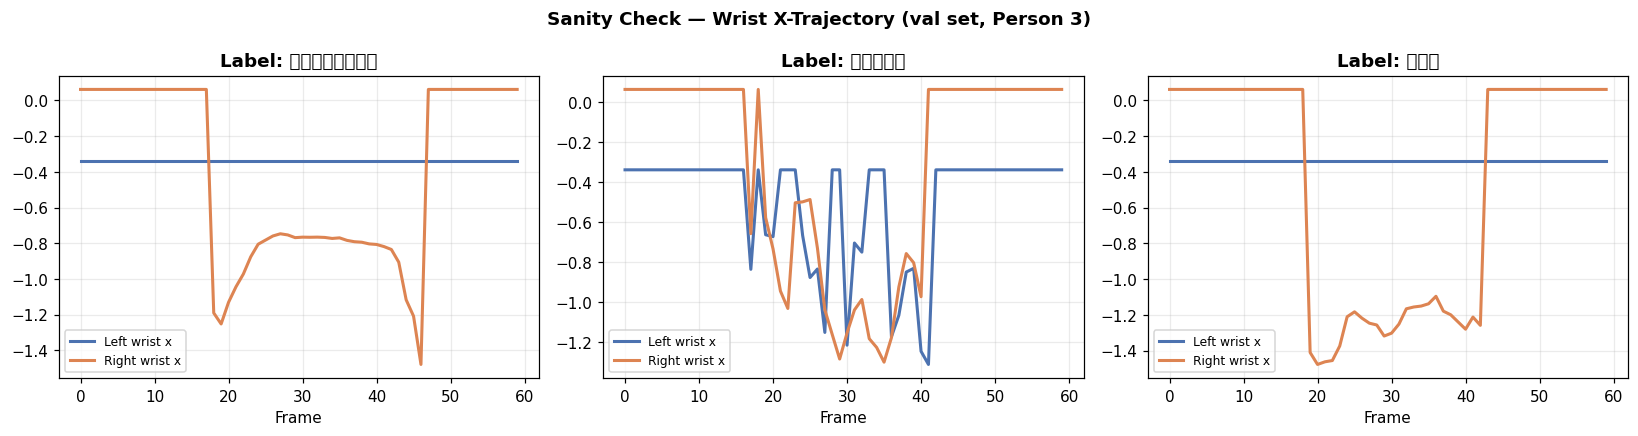

Train source files : 1200
X_val shape        : (10, 60, 404)
X_test shape       : (10, 60, 404)
Preprocessing complete. Run 03_training.ipynb next.


In [11]:
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110

LEFT_WRIST_X  = 0
RIGHT_WRIST_X = 63

rng_vis  = np.random.default_rng(0)
pick_idx = rng_vis.choice(len(X_val), size=3, replace=False)
frames   = np.arange(TARGET_FRAMES)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sanity Check — Wrist X-Trajectory (val set, Person 3)', fontsize=12, fontweight='bold')

for ax, idx in zip(axes, pick_idx):
    seq        = X_val[idx]
    label_name = classes[y_val[idx]]
    ax.plot(frames, seq[:, LEFT_WRIST_X],  label='Left wrist x',  color='#4C72B0', linewidth=2)
    ax.plot(frames, seq[:, RIGHT_WRIST_X], label='Right wrist x', color='#DD8452', linewidth=2)
    ax.set_title(f'Label: {label_name}', fontweight='bold')
    ax.set_xlabel('Frame'); ax.legend(fontsize=8); ax.grid(True, alpha=0.25)

plt.tight_layout(); plt.show()

kp_train_files = sorted((OUTPUT_DIR / 'keypoints' / 'train').glob('*.npy'))
print(f'Train source files : {len(kp_train_files)}')
print(f'X_val shape        : {X_val.shape}')
print(f'X_test shape       : {X_test.shape}')
print('Preprocessing complete. Run 03_training.ipynb next.')
